# Dragonfly report plots


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from tqdm.auto import trange

try:
    from matplotlib_tufte import setup as setup_tufte
    setup_tufte()
    TUFTE_BACKEND = "matplotlib_tufte"
except ImportError:
    setup_tufte = None
    TUFTE_BACKEND = "fallback"
    print("matplotlib_tufte not found; using a local minimalist fallback style.")

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "miniproject"))

from flygym.compose import ActuatorType
from miniproject.simulation import MiniprojectSimulation
from submission.controller import Controller

FIG_DIR = ROOT / "miniproject" / "report_figures"
VIDEO_DIR = ROOT / "miniproject" / "report_videos"
DATA_DIR = ROOT / "miniproject" / "report_data"
FIG_DIR.mkdir(parents=True, exist_ok=True)
VIDEO_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "legend.frameon": False,
})
if TUFTE_BACKEND == "fallback":
    plt.rcParams.update({
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,
        "font.size": 9,
        "axes.labelsize": 9,
        "axes.titlesize": 10,
    })
print("tufte backend:", TUFTE_BACKEND)

PALETTE = {
    "red": "#c33d2e",
    "looming": "#222222",
    "danger": "#4a8f4a",
    "velocity": "#2f6f9f",
    "state": "#7a5c99",
    "visible": "#9b7d2d",
    "attack": "#8f1d1d",
}

print("figures:", FIG_DIR)
print("videos:", VIDEO_DIR)
print("data:", DATA_DIR)

tufte backend: matplotlib_tufte
figures: C:\Users\Xgili\OneDrive\Documents\EPFL\MA4\CoBaR\cobar-miniproject-2026\miniproject\report_figures
videos: C:\Users\Xgili\OneDrive\Documents\EPFL\MA4\CoBaR\cobar-miniproject-2026\miniproject\report_videos
data: C:\Users\Xgili\OneDrive\Documents\EPFL\MA4\CoBaR\cobar-miniproject-2026\miniproject\report_data


## Rollout helpers

In [2]:
def dragonfly_sim_state(sim):
    if bool(getattr(sim, "_dragonfly_is_open_loop", False)):
        return "open_loop"
    if bool(getattr(sim, "_dragonfly_is_looming", False)):
        return "looming"
    return "rest"


def step_controlled_simulation(sim, controller):
    joint_angles, adhesion = controller.step(sim)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion)
    sim.step()


def run_dragonfly_rollout(
    *,
    seed,
    n_steps=35000,
    render=False,
    video_path=None,
    camera_res=(512, 512),
    stop_after_panic_steps=None,
):
    sim = MiniprojectSimulation(level=4, seed=seed, camera_res=camera_res)
    controller = Controller(sim)
    records = []
    panic_seen_at = None

    for _ in trange(n_steps, desc=f"seed {seed}"):
        step_controlled_simulation(sim, controller)
        if render:
            sim.render_as_needed()

        mode = controller.dragonfly_mode
        if panic_seen_at is None and mode == "panic_escape":
            panic_seen_at = sim._curr_step

        records.append({
            "step": sim._curr_step,
            "time_s": sim.time,
            "red_score": controller.dragonfly_red_score,
            "looming": controller.dragonfly_looming,
            "visible": controller.dragonfly_visible,
            "attack": controller.dragonfly_attack,
            "mode": mode,
            "danger_score": controller.dragonfly_danger_score,
            "forward_velocity": controller.current_velocity[0],
            "dragonfly_state": dragonfly_sim_state(sim),
        })

        if (
            stop_after_panic_steps is not None
            and panic_seen_at is not None
            and sim._curr_step - panic_seen_at >= stop_after_panic_steps
        ):
            break

    df = pd.DataFrame(records)

    if video_path is not None:
        video_path = Path(video_path)
        video_path.parent.mkdir(parents=True, exist_ok=True)
        sim.renderer.save_video(video_path)
        print("saved video:", video_path)

    return sim, controller, df


def display_video(path, width=900):
    path = Path(path).resolve()
    try:
        src = path.relative_to(ROOT).as_posix()
    except ValueError:
        src = path.as_posix()
    display(HTML(f'<video src="{src}" width="{width}" controls loop muted></video>'))


def save_rollout_data(df, name):
    csv_path = DATA_DIR / f"{name}.csv"
    pkl_path = DATA_DIR / f"{name}.pkl"
    df.to_csv(csv_path, index=False)
    df.to_pickle(pkl_path)
    print("saved data:", csv_path)
    print("saved data:", pkl_path)
    return csv_path, pkl_path


def load_rollout_data(name):
    pkl_path = DATA_DIR / f"{name}.pkl"
    csv_path = DATA_DIR / f"{name}.csv"
    if pkl_path.exists():
        return pd.read_pickle(pkl_path)
    return pd.read_csv(csv_path)

## Figure 1: clean dragonfly signal processing


In [ ]:
clean_sim, clean_controller, clean_df = run_dragonfly_rollout(
    seed=42,
    n_steps=100000,
    render=False,
)

save_rollout_data(clean_df, "dragonfly_clean_seed42_100k")
clean_df.head(), clean_df.tail()

seed 42:   0%|          | 0/100000 [00:00<?, ?it/s]

If the rollout has already been saved, reload it here and skip the simulation cell above.

In [ ]:
# clean_df = load_rollout_data("dragonfly_clean_seed42")
# burst_df = load_rollout_data("dragonfly_burst_seed0")
# failure_df = load_rollout_data("dragonfly_failure_seed1")

C:\Users\Xgili\AppData\Local\Temp\ipykernel_7232\1740575702.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(png, bbox_inches="tight")


saved: C:\Users\Xgili\OneDrive\Documents\EPFL\MA4\CoBaR\cobar-miniproject-2026\miniproject\report_figures\fig_dragonfly_signal_processing.png
saved: C:\Users\Xgili\OneDrive\Documents\EPFL\MA4\CoBaR\cobar-miniproject-2026\miniproject\report_figures\fig_dragonfly_signal_processing.pdf


C:\Users\Xgili\AppData\Local\Temp\ipykernel_7232\1740575702.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(pdf, bbox_inches="tight")


,time_s,step,dragonfly_state,mode,red_score,looming,visible,attack
0,0.2001,2001,looming,watch,0.000074,0.000043,False,False
10181,1.2182,12182,open_loop,watch,0.000627,0.000000,True,False
10185,1.2186,12186,open_loop,panic_escape,0.001319,0.001000,True,True
15052,1.7053,17053,open_loop,normal,0.000000,0.000000,False,False
15182,1.7183,17183,rest,normal,0.000000,0.000000,False,False


c:\Users\Xgili\OneDrive\Documents\EPFL\MA4\CoBaR\cobar-miniproject-2026\.venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
c:\Users\Xgili\OneDrive\Documents\EPFL\MA4\CoBaR\cobar-miniproject-2026\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


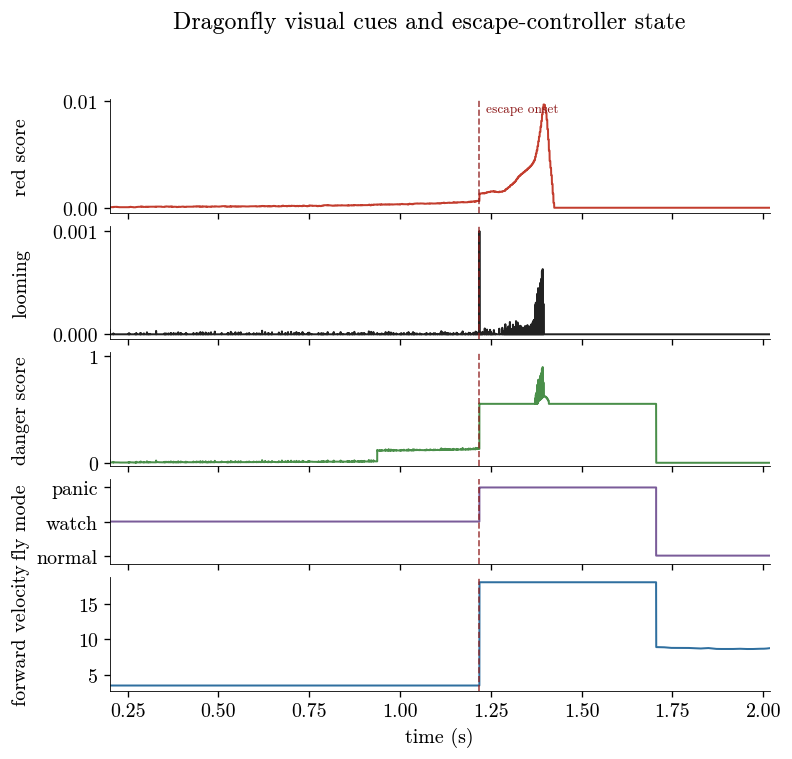

In [7]:
MODE_CODE = {"normal": 0, "watch": 1, "panic_escape": 2}


def first_escape_onset(df):
    panic_rows = df[df["mode"] == "panic_escape"]
    if panic_rows.empty:
        return None
    return float(panic_rows.iloc[0].time_s)


def add_escape_onset_marker(ax, onset_time):
    if onset_time is None:
        return
    ax.axvline(onset_time, color=PALETTE["attack"], lw=1.0, ls="--", alpha=0.8)


def transition_table(df):
    """Show exact times where the dragonfly state or fly mode changes."""
    changed = df[
        df["dragonfly_state"].ne(df["dragonfly_state"].shift())
        | df["mode"].ne(df["mode"].shift())
    ].copy()
    return changed[["time_s", "step", "dragonfly_state", "mode", "red_score", "looming", "visible", "attack"]]


def plot_clean_signal_figure(df, out_stem="fig_dragonfly_signal_processing"):
    fig, axs = plt.subplots(
        5,
        1,
        figsize=(7.1, 6.4),
        sharex=True,
        gridspec_kw={"height_ratios": [1.0, 1.0, 1.0, 0.75, 1.0], "hspace": 0.12},
    )
    fig.suptitle("Dragonfly visual cues and escape-controller state", y=0.995)

    axs[0].plot(df.time_s, df.red_score, color=PALETTE["red"], lw=1.2)
    axs[0].set_ylabel("red score")

    axs[1].plot(df.time_s, df.looming, color=PALETTE["looming"], lw=1.2)
    axs[1].set_ylabel("looming")

    axs[2].plot(df.time_s, df.danger_score, color=PALETTE["danger"], lw=1.2)
    axs[2].set_ylabel("danger score")
    axs[2].set_ylim(-0.03, 1.03)

    escape_onset = first_escape_onset(df)

    axs[3].step(
        df.time_s,
        df["mode"].map(MODE_CODE),
        where="post",
        color=PALETTE["state"],
        lw=1.2,
    )
    axs[3].set_yticks([0, 1, 2], ["normal", "watch", "panic"])
    axs[3].set_ylim(-0.25, 2.25)
    axs[3].set_ylabel("fly mode")

    axs[4].plot(df.time_s, df.forward_velocity, color=PALETTE["velocity"], lw=1.2)
    axs[4].set_ylabel("forward velocity")
    axs[4].set_xlabel("time (s)")

    if escape_onset is not None:
        axs[0].annotate(
            "escape onset",
            xy=(escape_onset, 1.0),
            xycoords=("data", "axes fraction"),
            xytext=(4, -2),
            textcoords="offset points",
            ha="left",
            va="top",
            color=PALETTE["attack"],
            fontsize=8,
        )

    for ax in axs:
        add_escape_onset_marker(ax, escape_onset)
        ax.margins(x=0)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
    fig.align_ylabels(axs)
    png = FIG_DIR / f"{out_stem}.png"
    pdf = FIG_DIR / f"{out_stem}.pdf"
    fig.savefig(png, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    print("saved:", png)
    print("saved:", pdf)
    return fig, axs


fig, axs = plot_clean_signal_figure(clean_df)
transition_table(clean_df)

## Video 1: burst response


In [10]:
burst_video_dir = VIDEO_DIR / "video_dragonfly_burst_seed0"
burst_sim, burst_controller, burst_df = run_dragonfly_rollout(
    seed=42,
    n_steps=40000,
    render=True,
    video_path=burst_video_dir,
    camera_res=(512, 512),
    stop_after_panic_steps=20000,
)

save_rollout_data(burst_df, "dragonfly_burst_seed42")
print(burst_df.groupby("mode").size())
print("Video folder:", burst_video_dir)

seed 42:   0%|          | 0/40000 [00:00<?, ?it/s]

saved video: C:\Users\Xgili\OneDrive\Documents\EPFL\MA4\CoBaR\cobar-miniproject-2026\miniproject\report_videos\video_dragonfly_burst_seed0
saved data: C:\Users\Xgili\OneDrive\Documents\EPFL\MA4\CoBaR\cobar-miniproject-2026\miniproject\report_data\dragonfly_burst_seed42.csv
saved data: C:\Users\Xgili\OneDrive\Documents\EPFL\MA4\CoBaR\cobar-miniproject-2026\miniproject\report_data\dragonfly_burst_seed42.pkl
mode
normal           4225
panic_escape     5376
watch           20585
dtype: int64
Video folder: C:\Users\Xgili\OneDrive\Documents\EPFL\MA4\CoBaR\cobar-miniproject-2026\miniproject\report_videos\video_dragonfly_burst_seed0


In [9]:
# Pick whichever camera is clearest for the report/video supplement.
for path in sorted(burst_video_dir.glob("*.mp4")):
    print(path.name)
    display_video(path, width=700)

birdeyecam.mp4


nmf-backcam.mp4


## Video 2: seed 1 failure case



In [ ]:
failure_video_dir = VIDEO_DIR / "video_dragonfly_failure_seed1"
failure_sim, failure_controller, failure_df = run_dragonfly_rollout(
    seed=1,
    n_steps=45000,
    render=True,
    video_path=failure_video_dir,
    camera_res=(512, 512),
    stop_after_panic_steps=12000,
)

save_rollout_data(failure_df, "dragonfly_failure_seed1")
print(failure_df.groupby("mode").size())
print("Video folder:", failure_video_dir)

In [ ]:
for path in sorted(failure_video_dir.glob("*.mp4")):
    print(path.name)
    display_video(path, width=700)